In [170]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords

In [ ]:
hate_df = pd.read_csv("yourown")

In [172]:
hate_df.head(10)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...
8,8,3,0,3,0,1,""" &amp; you might not get ya bitch back &amp; ..."
9,9,3,1,2,0,1,""" @rhythmixx_ :hobbies include: fighting Maria..."


In [173]:
emotion_df = pd.read_csv("/content/drive/MyDrive/Portofolio J/Multi Detector/emotion.csv")

In [174]:
emotion_df.head(100)

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
95,95,i feel like i havent had a moment to breathe s...,1
96,96,i am feeling helpless because he is who the re...,0
97,97,i had not been in a convertible in many many y...,1
98,98,i feel like a whiner because my pain is really...,0


In [175]:
violence_df = pd.read_csv("/content/drive/MyDrive/Portofolio J/Multi Detector/gender-based-violence-tweet-classification-challenge/Train.csv")

In [176]:
violence_df.head(10)

,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence
5,ID_0052TYKI,"Yes men rape women. But women also rape men, y...",sexual_violence
6,ID_0058QG76,"My Husband Beats Me Frequently, Wife Tells Cou...",Physical_violence
7,ID_005VM1DJ,Pretty sure he raped a 16yr old girl with 2 fr...,sexual_violence
8,ID_0060BW8R,TW sorry to hear that and yeah he recently th...,sexual_violence
9,ID_007FAIEI,"""I understand that... My father was abusive as...",sexual_violence


data preprocessing

In [177]:
emotion_df.drop(columns = ['Unnamed: 0'], inplace = True)
violence_df.drop(columns = ['Tweet_ID'], inplace = True)
hate_df = hate_df[['tweet', 'class']]

In [178]:
emotion_df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [179]:
violence_df.head()

,tweet,type
0,Had a dream i got raped last night. By a guy i...,sexual_violence
1,he thought the word raped means sex and told m...,sexual_violence
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,Chessy Prout can do better by telling the trut...,sexual_violence


In [180]:
hate_df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [181]:
emotion_df.columns, violence_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['tweet', 'type'], dtype='object'),
 Index(['tweet', 'class'], dtype='object'))

In [182]:
violence_df.rename(columns = {'tweet' : 'text', 'type' : 'label'}, inplace = True)
hate_df.rename(columns = {'tweet' : 'text', 'class' : 'label'}, inplace = True)

In [183]:
emotion_df.columns, violence_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [184]:
emotion_df.isna().sum(), violence_df.isna().sum(), hate_df.isna().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [185]:
emotion_df.shape, violence_df.shape, hate_df.shape

((416809, 2), (39650, 2), (24783, 2))

extract 12 thousand rows dari tiap dataset


In [186]:
emotion_df['label'].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


In [187]:
emo_df = pd.DataFrame()
for i in range(6):
  subset = emotion_df[emotion_df['label'] == i].sample(n=2000, random_state=22)
  emo_df = pd.concat([emo_df, subset])

In [188]:
emo_df.shape

(12000, 2)

In [189]:
emotion_df = emo_df.copy()

In [190]:
emotion_df['label'].value_counts()

,count
label,
0,2000
1,2000
2,2000
3,2000
4,2000
5,2000


In [191]:
violence_df['label'].value_counts()

,count
label,
sexual_violence,32648
Physical_violence,5946
emotional_violence,651
economic_violence,217
Harmful_Traditional_practice,188


In [192]:
sexual_vio = violence_df[violence_df['label'] == 'sexual_violence'].sample(n=4998, random_state=22)
violence_df = violence_df[violence_df['label'] != 'sexual_violence']


In [193]:
violence_df.shape

(7002, 2)

In [194]:
violence_df = pd.concat([violence_df, sexual_vio], axis=0)

In [195]:
violence_df.shape

(12000, 2)

In [196]:
hate_df['label'].value_counts()

,count
label,
1,19190
2,4163
0,1430


In [197]:
h_df = hate_df[hate_df['label'] == 1].sample(n=6407, random_state=22)
hate_df = hate_df[hate_df['label'] != 1]

In [198]:
hate_df.shape

(5593, 2)

In [199]:
hate_df = pd.concat([hate_df, h_df], axis=0)

In [200]:
hate_df.shape

(12000, 2)

In [201]:
emotion_df.shape, violence_df.shape, hate_df.shape

((12000, 2), (12000, 2), (12000, 2))

In [202]:
emotion_df.head(5)

,text,label
98053,i believe our social and crime problems around...,0
266567,ive been guilty of it and afterward i feel awf...,0
163879,i feel the need to apologize for the messy loo...,0
132605,i feel the onus of a heartbroken fever washing...,0
32085,i feel need to be stressed to be shared,0


In [203]:
hate_df.head(5)

,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
40,""" momma said no pussy cats inside my doghouse """,2
63,"""@Addicted2Guys: -SimplyAddictedToGuys http://...",2
66,"""@AllAboutManFeet: http://t.co/3gzUpfuMev"" woo...",2
67,"""@Allyhaaaaa: Lemmie eat a Oreo &amp; do these...",2


In [204]:
violence_df.head(5)

,text,label
6,"My Husband Beats Me Frequently, Wife Tells Cou...",Physical_violence
29,"Best thing for me to do, is remain silent when...",Physical_violence
30,"My husband will never beat me, Bambam denies r...",Physical_violence
33,"theyre like, i just wanna be a baby maker with...",Physical_violence
35,"I was in England for a week, the longest I’ve ...",Physical_violence


Label Encoding

In [205]:
label_encoder = LabelEncoder()
violence_df['label'] = label_encoder.fit_transform(violence_df['label'])

In [206]:
violence_df['label'].unique()

array([1, 3, 0, 2, 4])

In [207]:
#stopwords removal
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [208]:
stop_words = set(stopwords.words('english'))

In [209]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [210]:
len(stop_words)

198

In [211]:
def remove_stopwords(text):
  all_words = nltk.word_tokenize(text)
  filtered_words = [word for word in all_words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

In [212]:
emotion_df['text'] = emotion_df['text'].apply(remove_stopwords)
violence_df['text'] = violence_df['text'].apply(remove_stopwords)
hate_df['text'] = hate_df['text'].apply(remove_stopwords)

In [213]:
violence_df.head(5)

,text,label
6,"Husband Beats Frequently , Wife Tells Court |",1
29,"Best thing , remain silent return work today ....",1
30,"husband never beat , Bambam denies rumour Tedd...",1
33,"theyre like , wan na baby maker zero sexual au...",1
35,"England week , longest ’ ever away . husband s...",1


Token & Padding

In [214]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [215]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([emotion_df['text'], violence_df['text'], hate_df['text']]))

In [216]:
emotion_seq = tokenizer.texts_to_sequences(emotion_df['text'])
violence_seq = tokenizer.texts_to_sequences(violence_df['text'])
hate_seq = tokenizer.texts_to_sequences(hate_df['text'])

In [217]:
emotion_df['text'].iloc[5]

'im feeling whiney mopey last night realized something wrong tooth'

In [218]:
emotion_seq[2:3]

[[1,
  70,
  1531,
  1748,
  89,
  3463,
  6820,
  17261,
  20,
  30,
  5058,
  200,
  2098,
  4680,
  17262,
  17263,
  286,
  257,
  142,
  30,
  1293,
  5059,
  103]]

In [219]:
max_length = 50
emotion_padded = pad_sequences(emotion_seq, maxlen=max_length, padding='post')
violence_padded = pad_sequences(violence_seq, maxlen=max_length, padding='post')
hate_padded = pad_sequences(hate_seq, maxlen=max_length, padding='post')

In [220]:
emotion_padded[2:3]

array([[    1,    70,  1531,  1748,    89,  3463,  6820, 17261,    20,
           30,  5058,   200,  2098,  4680, 17262, 17263,   286,   257,
          142,    30,  1293,  5059,   103,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0]], dtype=int32)

In [221]:
import numpy as np

In [222]:
#generate labels
emotion_labels = np.array(emotion_df['label'])
violence_labels = np.array(violence_df['label'])
hate_labels = np.array(hate_df['label'])

model def

In [223]:
emotion_input = emotion_padded
violence_input = violence_padded
hate_input = hate_padded

In [224]:
from tensorflow import keras

In [225]:
emotion_input_layer = keras.layers.Input(shape=(max_length,), name ='emotion_input')
violence_input_layer = keras.layers.Input(shape=(max_length,), name= 'violence_input')
hate_input_layer = keras.layers.Input(shape=(max_length,), name = 'hate_input')

In [226]:
embedding_layer = keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=100)

In [227]:
emotion_embedding = embedding_layer(emotion_input_layer)
violence_embedding = embedding_layer(violence_input_layer)
hate_embedding = embedding_layer(hate_input_layer)

In [228]:
share_lstm = keras.layers.LSTM(64, return_sequences=True)

In [229]:
emotion_lstm = share_lstm(emotion_embedding)
violence_lstm = share_lstm(violence_embedding)
hate_lstm = share_lstm(hate_embedding)

In [230]:
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

In [231]:
emotion_features = shared_pooling(emotion_lstm)


In [232]:
violence_features = shared_pooling(violence_lstm)
hate_features = shared_pooling(hate_lstm)

In [233]:
len(emotion_df['label'].unique()), len(violence_df['label'].unique()), len(hate_df['label'].unique())


(6, 5, 3)

In [234]:
emotion_output = keras.layers.Dense(6, activation = 'softmax', name = 'emotion_output')(emotion_features)
violence_output = keras.layers.Dense(5, activation = 'softmax', name = 'violence_output')(violence_features)
hate_output = keras.layers.Dense(3, activation = 'softmax', name = 'hate_output')(hate_features)

In [235]:
model = keras.models.Model(inputs = [emotion_input_layer, violence_input_layer, hate_input_layer],
                           outputs = [emotion_output, violence_output, hate_output])

model.compile(optimizer = 'adam',
              loss = {
                  'emotion_output' : 'sparse_categorical_crossentropy',
                  'violence_output' :'sparse_categorical_crossentropy',
                  'hate_output' : 'sparse_categorical_crossentropy'
              },
              metrics = {
                  'emotion_output': 'accuracy',
                  'violence_output': 'accuracy',
                  'hate_output':'accuracy'
              })

In [236]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emotion_input       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_input      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 50, 100)   │  4,160,400 │ emotion_input[0]… │
│ (Embedding)         │                   │            │ violence_input[0… │
│                     │                   │            │ hate_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 50, 64)    │     42,240 │ embedding_2[0][0… │
│                     │                   │            │ embedding_2[1][0… │
│                     │                   │            │ embedding_2[2][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ lstm_2[0][0],     │
│ (GlobalAveragePool… │                   │            │ lstm_2[1][0],     │
│                     │                   │            │ lstm_2[2][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_output     │ (None, 5)         │        325 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_output (Dense) │ (None, 3)         │        195 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,203,550 (16.04 MB)

 Trainable params: 4,203,550 (16.04 MB)

 Non-trainable params: 0 (0.00 B)

In [237]:
model.fit(x = {'emotion_input': emotion_input,
          'violence_input':violence_input,
          'hate_input':hate_input},
          y = {'emotion_output':emotion_labels,
          'violence_output':violence_labels,
          'hate_output':hate_labels},
          epochs = 10,
          batch_size = 4)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 264s 86ms/step - emotion_output_accuracy: 0.3394 - emotion_output_loss: 1.5318 - hate_output_accuracy: 0.7475 - hate_output_loss: 0.6652 - loss: 2.4579 - violence_output_accuracy: 0.9183 - violence_output_loss: 0.2609
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 262s 86ms/step - emotion_output_accuracy: 0.7576 - emotion_output_loss: 0.6392 - hate_output_accuracy: 0.8593 - hate_output_loss: 0.3998 - loss: 1.0946 - violence_output_accuracy: 0.9827 - violence_output_loss: 0.0556
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 259s 86ms/step - emotion_output_accuracy: 0.9391 - emotion_output_loss: 0.1917 - hate_output_accuracy: 0.9121 - hate_output_loss: 0.2357 - loss: 0.4360 - violence_output_accuracy: 0.9983 - violence_output_loss: 0.0085
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 260s 87ms/step - emotion_output_accuracy: 0.9649 - emotion_output_loss: 0.1013 - hate_output_accuracy: 0.9559 - hate_output_loss: 0.1204 - loss: 0.2275 - violence_output_accuracy

In [239]:
prediction = model.predict({'emotion_input':emotion_input,
                           'violence_input':violence_input,
                           'hate_input':hate_input})

375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step


In [240]:
prediction

[array([[9.9956900e-01, 3.3921664e-04, 2.2371428e-06, 4.8265033e-06,
         4.8867114e-05, 3.5755456e-05],
        [9.9998444e-01, 1.1409669e-05, 6.1024394e-08, 1.4893804e-07,
         1.6600931e-06, 2.1168012e-06],
        [9.9992770e-01, 3.4331300e-05, 6.7067521e-07, 3.7156276e-06,
         1.8665818e-05, 1.4839709e-05],
        ...,
        [9.3688641e-07, 8.5177831e-05, 1.0716225e-06, 9.4131065e-07,
         1.3714361e-05, 9.9989814e-01],
        [7.5023067e-08, 5.5951573e-06, 1.4408778e-07, 2.9101477e-07,
         3.6747936e-06, 9.9999017e-01],
        [3.4540214e-08, 4.1100811e-06, 1.2540845e-07, 3.6815467e-07,
         2.2650051e-05, 9.9997264e-01]], dtype=float32),
 array([[1.66338457e-10, 9.99999940e-01, 2.38497527e-10, 3.91122638e-12,
         2.89275184e-11],
        [9.68381528e-07, 9.99989808e-01, 6.03088210e-06, 2.81199641e-06,
         2.84754407e-07],
        [1.05052378e-09, 9.99999940e-01, 5.59805036e-10, 8.70687984e-12,
         3.28444633e-10],
        ...,
      

In [241]:
emotion_pred = np.argmax(prediction[0], axis=1)
violence_pred = np.argmax(prediction[1], axis=1)
hate_pred = np.argmax(prediction[2], axis=1)

In [245]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [246]:
def plot_cm(true, pred, title, labels):
  cf = confusion_matrix(true, pred, normalize = 'true')
  plt.figure(figsize = (7, 6))
  sns.heatmap(cf, annot = True, cmap = 'Blues', xticklabels=labels, yticklabels = labels)
  plt.title(title)
  plt.ylabel('Actual')
  plt.xlabel('Prediction')

emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
violence_labels_text = ['sexual_violence', 'physical_violence', 'emotional_violence', 'Harmful_traditional_practice', 'economic violence']
hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

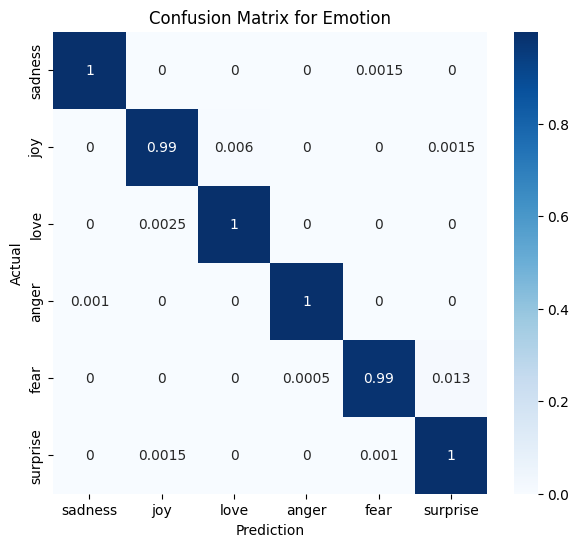

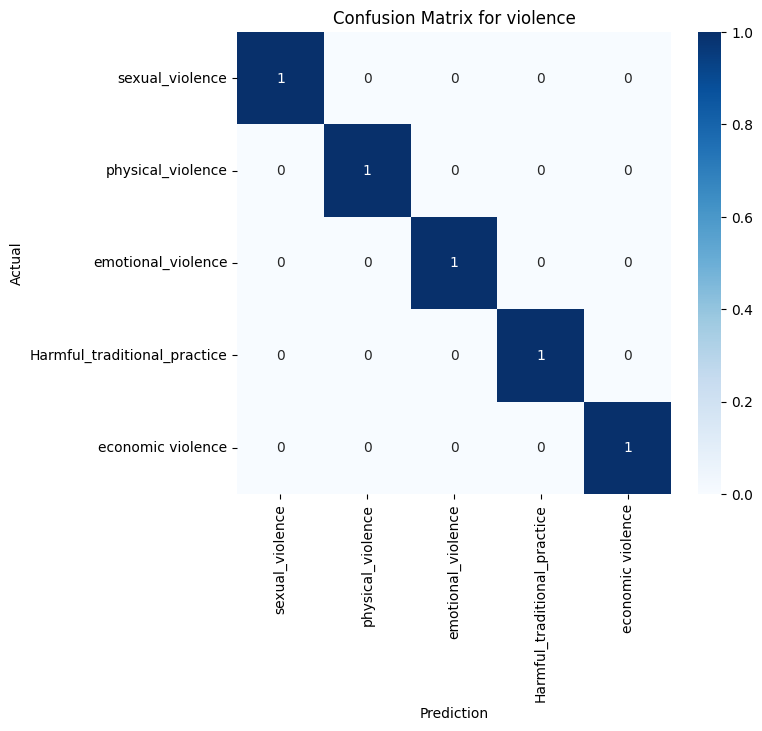

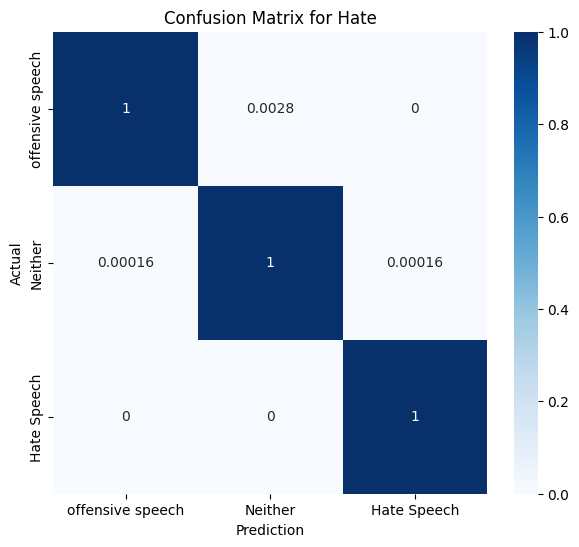

In [247]:
plot_cm(emotion_labels, emotion_pred, 'Confusion Matrix for Emotion', emotion_labels_text)
plot_cm(violence_labels, violence_pred, 'Confusion Matrix for violence', violence_labels_text)
plot_cm(hate_labels, hate_pred, 'Confusion Matrix for Hate', hate_labels_text)

In [ ]:
model.save('yourown')

testing

In [248]:
def classify_text(input_text):
  #preprocess input text
  input_text_cleaned = remove_stopwords(input_text)
  input_sequence = tokenizer.texts_to_sequences([input_text_cleaned])
  input_padded = pad_sequences(input_sequence, maxlen = max_length, padding = 'post')

  #prediction
  predictions = model.predict({'emotion_input' : input_padded,
                            'violence_input' : input_padded,
                            'hate_input' : input_padded})
  emotion_pred = np.argmax(predictions[0], axis = 1)[0]
  violence_pred = np.argmax(predictions[1], axis = 1)[0]
  hate_pred = np.argmax(predictions[2], axis = 1)[0]

  major_labels = ['Emotion', 'Violence', 'Hate']
  major_label_index = np.argmax([np.max(predictions[0]), np.max(predictions[1]), np.max(predictions[2])])
  major_label = major_labels[major_label_index]

  emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
  violence_labels_text = ['sexual_violence', 'physical_violence', 'emotional_violence', 'Harmful_traditional_practice', 'economic violence']
  hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

  if major_label == 'Emotion':
    sub_label = emotion_labels_text[emotion_pred]
  elif major_label == 'Violence':
    sub_label = violence_labels_text[violence_pred]
  else:
    sub_label = hate_labels_text[hate_pred]

  return major_label, sub_label

In [249]:
import ipywidgets as widgets
from IPython.display import display

In [250]:
input_text_widget = widgets.Text(
    description = 'Input text : ',
    placeholder = 'Enter you text'
)

In [251]:
button = widgets.Button(description = 'classify')

In [252]:
output = widgets.Output()

In [ ]:
def on_button_click(b):
  with output:
    output.clear_output() 
    input_text = input_text_widget.value
    major_label, sub_label = classify_text(input_text)
    print(f'Major Label : {major_label}')
    print(f'Sub Label : {sub_label}')

button.on_click(on_button_click)

In [ ]:
display(input_text_widget, button, output)